# Homework 1 
## Task 1

In [22]:
# Import libraries for data manipulation and visualization.
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

In [23]:
# Load US quarterly GDP from CSV and set the index to a quarterly period index.
# Print the first rows and summary statistics to inspect the series.
gdp = pd.read_csv('GDP.csv', index_col='observation_date', parse_dates=True)
gdp.index = pd.PeriodIndex(gdp.index, freq='Q')  # Set quarterly frequency
print(gdp.head())
print(gdp.describe())

                      GDP
observation_date         
1947Q1            243.164
1947Q2            245.968
1947Q3            249.585
1947Q4            259.745
1948Q1            265.742
                GDP
count    308.000000
mean    7171.903451
std     7425.232231
min      243.164000
25%      802.669250
50%     4340.830000
75%    12360.783750
max    28424.722000


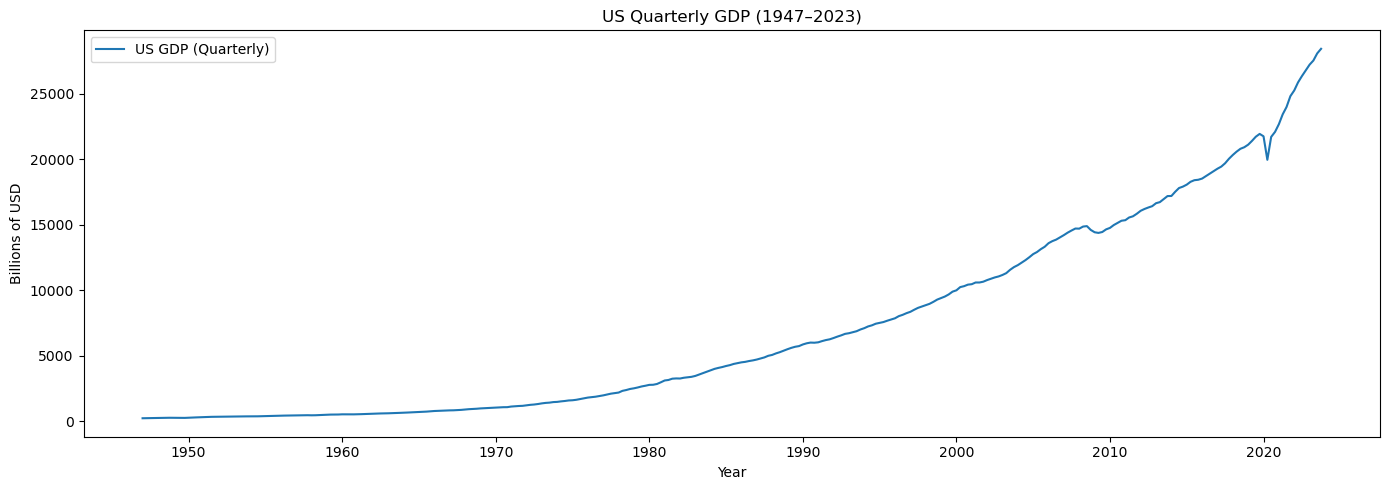

In [24]:
# Convert period index to timestamps for plotting.
# Plot the full US quarterly GDP time series (1947–2023) in billions of USD.
gdp.index = gdp.index.to_timestamp()
plt.figure(figsize=(14, 5))
plt.plot(gdp, label='US GDP (Quarterly)')
plt.title('US Quarterly GDP (1947–2023)')
plt.xlabel('Year')
plt.ylabel('Billions of USD')
plt.legend()
plt.tight_layout()
plt.show()

GDP grows exponentially over time — the variance increases as the level increases. This means I should use multiplicative decomposition

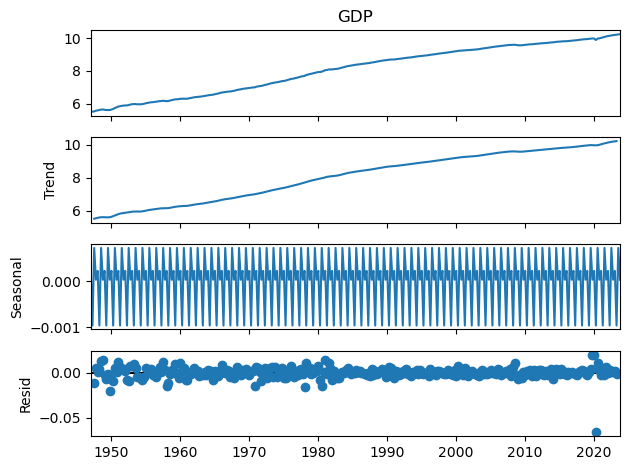

In [25]:
# Decompose GDP into trend, seasonal, and residual components.
# Use log-transformed GDP and additive model with quarterly period (4); plot all components.
from statsmodels.tsa.seasonal import seasonal_decompose
import numpy as np
gdp_log = np.log(gdp['GDP'])

decomp = seasonal_decompose(gdp_log, model='additive', period=4)
decomp.plot()
plt.tight_layout()
plt.show()

In [26]:
# Run Augmented Dickey-Fuller test on raw GDP to check for stationarity.
# Print ADF statistic, p-value, and critical values; p > 0.05 indicates non-stationary series.
from statsmodels.tsa.stattools import adfuller

result = adfuller(gdp['GDP'])
print(f'ADF Statistic: {result[0]:.4f}')
print(f'p-value: {result[1]:.4f}')
print(f'Critical Values: {result[4]}')

ADF Statistic: 8.8164
p-value: 1.0000
Critical Values: {'1%': np.float64(-3.4519023023726696), '5%': np.float64(-2.8710320399170537), '10%': np.float64(-2.57182745012602)}


ADF after log + first diff: p = 0.0000


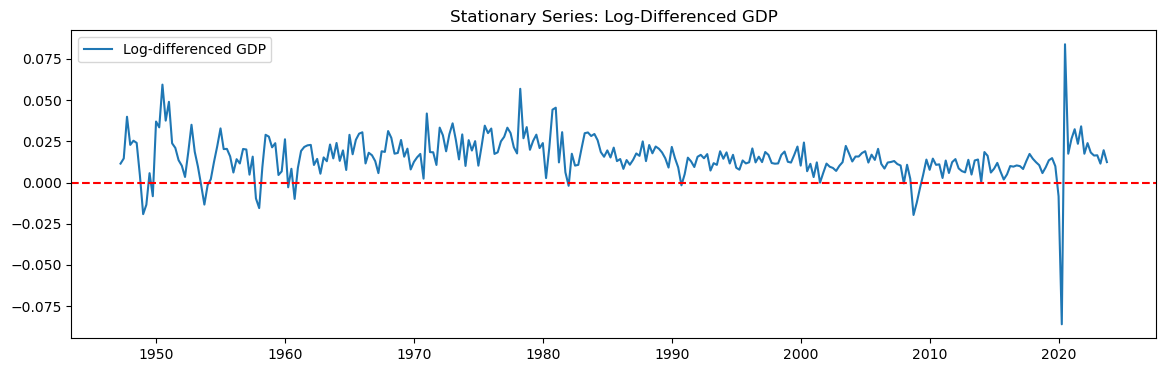

In [27]:
# Make the series stationary: log transform (stabilize variance) then first difference (remove trend).
# Re-run ADF on differenced series; plot the stationary log-differenced GDP.
# Step 1: Log transform (stabilizes variance)
gdp_log = np.log(gdp['GDP'])

# Step 2: First difference (removes trend) → d = 1
gdp_diff = gdp_log.diff().dropna()

# Re-test ADF
result2 = adfuller(gdp_diff)
print(f'ADF after log + first diff: p = {result2[1]:.4f}')

# If still non-stationary, second difference → d = 2
# Usually d=1 is enough for GDP

plt.figure(figsize=(14,4))
plt.plot(gdp_diff, label='Log-differenced GDP')
plt.axhline(0, color='red', linestyle='--')
plt.title('Stationary Series: Log-Differenced GDP')
plt.legend()
plt.show()

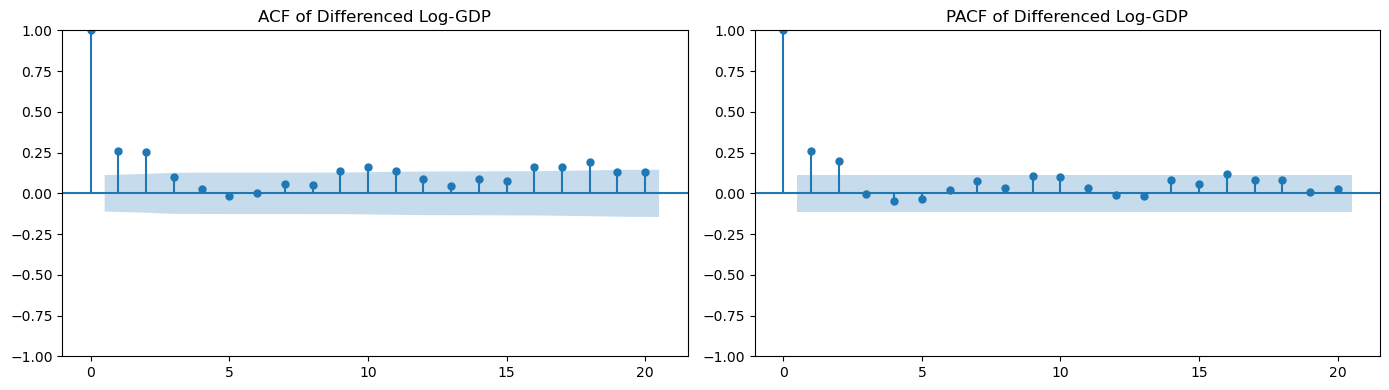

In [28]:
# Plot ACF and PACF of the stationary (log-differenced) GDP series.
# Used to choose ARIMA orders p and q (e.g., PACF cutoff → p, ACF cutoff → q).
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
plot_acf(gdp_diff, lags=20, ax=axes[0], title='ACF of Differenced Log-GDP')
plot_pacf(gdp_diff, lags=20, ax=axes[1], title='PACF of Differenced Log-GDP')
plt.tight_layout()
plt.show()

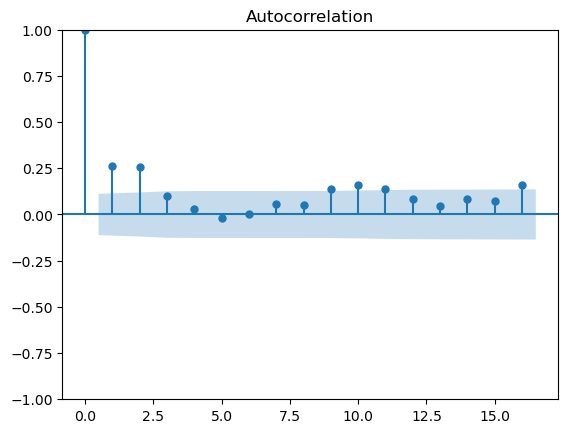

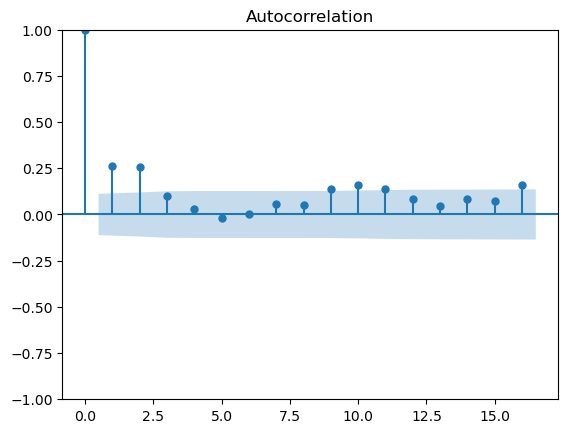

In [29]:
# Plot ACF of differenced GDP with 16 lags (compact view for seasonal/order checks).
plot_acf(gdp_diff, lags=16)

In [30]:
# Split GDP into 80% training and 20% test for out-of-sample evaluation.
# Print train/test sizes and date ranges.
n = len(gdp)
split = int(n * 0.80)
train = gdp['GDP'][:split]
test = gdp['GDP'][split:]
print(f"Train size: {len(train)} quarters")
print(f"Test size:  {len(test)} quarters")
print(f"Training period: {train.index[0]} to {train.index[-1]}")
print(f"Test period:     {test.index[0]} to {test.index[-1]}")

Train size: 246 quarters
Test size:  62 quarters
Training period: 1947-01-01 00:00:00 to 2008-04-01 00:00:00
Test period:     2008-07-01 00:00:00 to 2023-10-01 00:00:00


In [31]:
# Fit SARIMA(1,1,1)(1,1,0,4) on log-transformed training GDP.
# Seasonal order 4 captures quarterly pattern; print fitted model summary.
from statsmodels.tsa.statespace.sarimax import SARIMAX
log_train = np.log(train)

model = SARIMAX(log_train,
                order=(1, 1, 1),           # p, d, q
                seasonal_order=(1, 1, 0, 4), # P, D, Q, s
                enforce_stationarity=False,
                enforce_invertibility=False)

results = model.fit(disp=False)
print(results.summary())

                                     SARIMAX Results                                      
Dep. Variable:                                GDP   No. Observations:                  246
Model:             SARIMAX(1, 1, 1)x(1, 1, [], 4)   Log Likelihood                 714.293
Date:                            Wed, 25 Feb 2026   AIC                          -1420.585
Time:                                    19:15:44   BIC                          -1406.730
Sample:                                01-01-1947   HQIC                         -1415.000
                                     - 04-01-2008                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.4647      0.132      3.531      0.000       0.207       0.723
ma.L1         -0.0886      0.157   

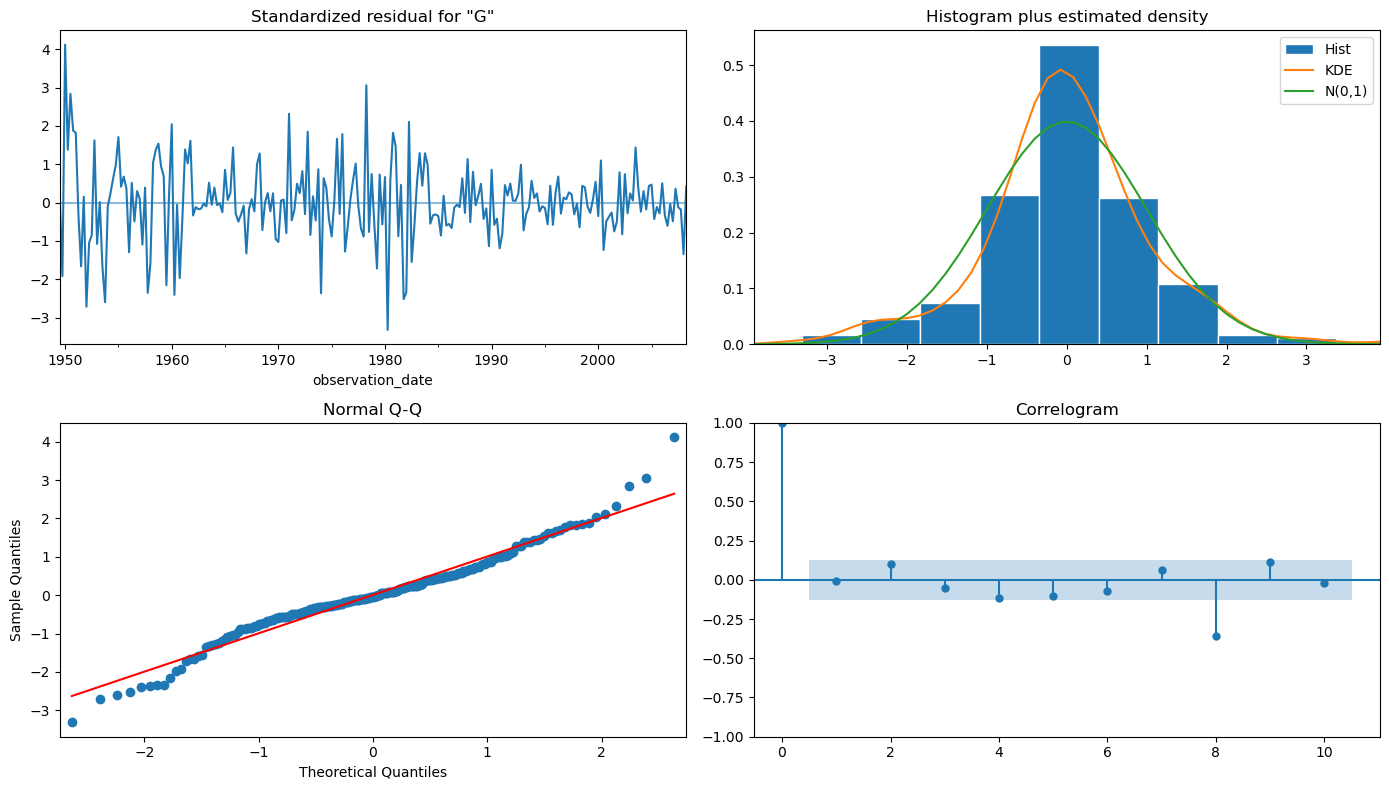

In [32]:
# Plot SARIMA residual diagnostics: standardized residuals, histogram, Q-Q, and correlogram.
# Used to check that residuals look like white noise.
results.plot_diagnostics(figsize=(14, 8))
plt.tight_layout()
plt.show()

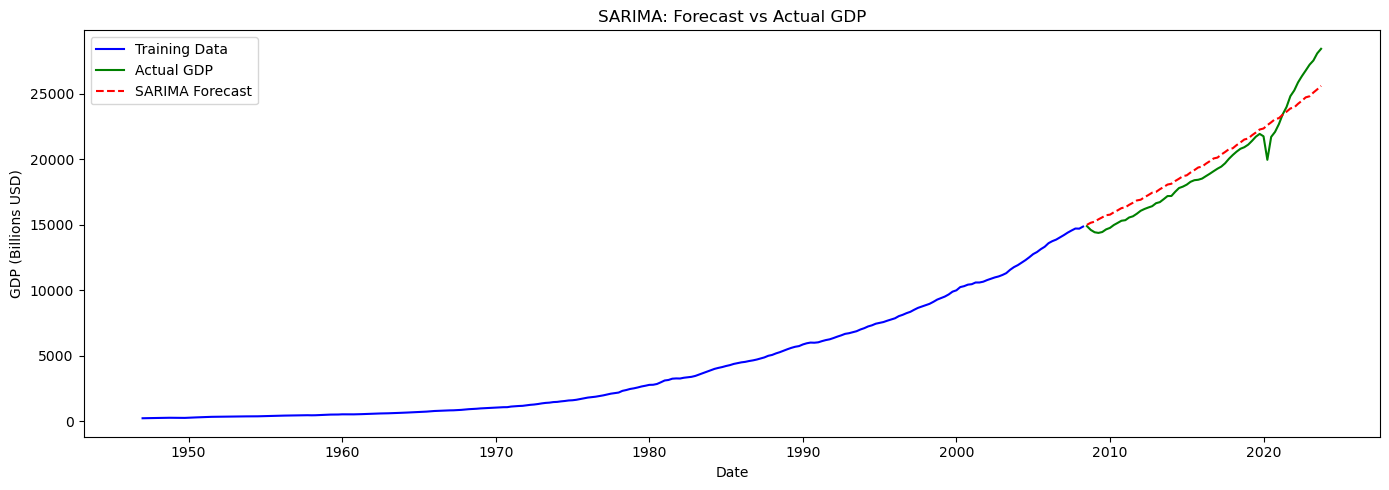

In [33]:
# Generate SARIMA forecast for the test period (in log space), then exp back to levels.
# Plot training data, actual test GDP, and forecast for comparison.
forecast_log = results.forecast(steps=len(test))
forecast = np.exp(forecast_log)
plt.figure(figsize=(14, 5))
plt.plot(train.index, train, label='Training Data', color='blue')
plt.plot(test.index, test, label='Actual GDP', color='green')
plt.plot(test.index, forecast.values, 
         label='SARIMA Forecast', linestyle='--', color='red')
plt.title('SARIMA: Forecast vs Actual GDP')
plt.xlabel('Date')
plt.ylabel('GDP (Billions USD)')
plt.legend()
plt.tight_layout()
plt.show()

In [34]:
# Evaluate forecast accuracy: compute RMSE, MAE, and MAPE vs actual test GDP.
# Lower values indicate better fit.
from sklearn.metrics import mean_squared_error, mean_absolute_error

rmse = np.sqrt(mean_squared_error(test, forecast))
mae  = mean_absolute_error(test, forecast)
mape = np.mean(np.abs((test.values - forecast.values) / test.values)) * 100
print(f'RMSE: {rmse:.2f}')
print(f'MAE:  {mae:.2f}')
print(f'MAPE: {mape:.2f}%')

RMSE: 1153.42
MAE:  992.00
MAPE: 5.08%


## Task 2
### 2.1

$$X_t = \phi_1 X_{t-1} + \epsilon_t$$

$$(1 - \phi_1 B) X_t = \epsilon_t$$

**Characteristic polynomial:**


$$\Phi(z) = 1 - \phi_1 z$$

$$1 - \phi_1 z = 0$$

$$z = \frac{1}{\phi_1}$$

We express $X_t$ in terms of $MA(\infty)$:


$$X_t = \epsilon_t + \phi_1 \epsilon_{t-1} + \phi_1^2 \epsilon_{t-2} + \dots = \sum_{j=0}^{\infty} \phi_1^j \epsilon_{t-j}$$

$$\text{Var}(X_t) = \sum_{j=0}^{\infty} \text{Var}(\phi_1^j \epsilon_{t-j})$$
$$\text{Var}(X_t) = \sum_{j=0}^{\infty} (\phi_1^j)^2 \text{Var}(\epsilon_{t-j})$$

$$\text{Var}(X_t) = \sum_{j=0}^{\infty} \phi_1^{2j} \sigma^2$$

This **converges** to a finite value iff $|\phi_1| < 1$

$$|z| = \frac{1}{|\phi_1|} > 1$$



### 2.2

$$X_t = \phi_1 X_{t-1} + \phi_2 X_{t-2} + \dots + \phi_p X_{t-p} + \varepsilon_t$$
$$\Phi(B) X_t = \varepsilon_t, \quad \phi(z) = 1 - \phi_1 z - \phi_2 z^2 - \dots - \phi_p z^p$$
By the Fundamental Theorem of Algebra:
$\phi(z)$ has exactly $p$ roots.
$$\phi(z) = -\phi_p \prod_{i=1}^{p} (z - z_i)$$
Moving Average Representation
$$X_t = \psi(B) \varepsilon_t$$
where $\psi(B) \phi(B) = 1$
Therefore:$$\psi(z) = \frac{1}{\phi(z)}$$
$\phi(z) \neq 0$ for $|z| \leq 1$, so $\psi(z)$ is analytic on the unit disk.$\sum \psi_j < \infty$, so $X_t = \sum \psi_j \varepsilon_{t-j}$ converges.

## Task 3

In [35]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

In [36]:
df = pd.read_csv('winequality-red.csv', sep=';')
print(df.head())


   fixed acidity  volatile acidity  citric acid  residual sugar  chlorides  \
0            7.4              0.70         0.00             1.9      0.076   
1            7.8              0.88         0.00             2.6      0.098   
2            7.8              0.76         0.04             2.3      0.092   
3           11.2              0.28         0.56             1.9      0.075   
4            7.4              0.70         0.00             1.9      0.076   

   free sulfur dioxide  total sulfur dioxide  density    pH  sulphates  \
0                 11.0                  34.0   0.9978  3.51       0.56   
1                 25.0                  67.0   0.9968  3.20       0.68   
2                 15.0                  54.0   0.9970  3.26       0.65   
3                 17.0                  60.0   0.9980  3.16       0.58   
4                 11.0                  34.0   0.9978  3.51       0.56   

   alcohol  quality  
0      9.4        5  
1      9.8        5  
2      9.8        5 

In [37]:
# Data Centering/Standardization: Compute mean and std, then standardize features
from sklearn.preprocessing import StandardScaler
X = df.drop('quality', axis=1)
y = df['quality']
feature_means = X.mean()
feature_stds = X.std()

print("Feature Means:")
print(feature_means)
print("\nFeature Standard Deviations:")
print(feature_stds)
X_standardized = (X - feature_means) / feature_stds

print("\nStandardized Data (first 5 rows):")
print(X_standardized.head())
print("\nMean of standardized features (should be ~0):")
print(X_standardized.mean())
print("\nStd of standardized features (should be ~1):")
print(X_standardized.std())

Feature Means:
fixed acidity            8.319637
volatile acidity         0.527821
citric acid              0.270976
residual sugar           2.538806
chlorides                0.087467
free sulfur dioxide     15.874922
total sulfur dioxide    46.467792
density                  0.996747
pH                       3.311113
sulphates                0.658149
alcohol                 10.422983
dtype: float64

Feature Standard Deviations:
fixed acidity            1.741096
volatile acidity         0.179060
citric acid              0.194801
residual sugar           1.409928
chlorides                0.047065
free sulfur dioxide     10.460157
total sulfur dioxide    32.895324
density                  0.001887
pH                       0.154386
sulphates                0.169507
alcohol                  1.065668
dtype: float64

Standardized Data (first 5 rows):
   fixed acidity  volatile acidity  citric acid  residual sugar  chlorides  \
0      -0.528194          0.961576    -1.391037       -0.453077 

In [38]:
n = X_standardized.shape[0]
p = X_standardized.shape[1]
X_std_array = X_standardized.values
cov_matrix = (1 / (n - 1)) * (X_std_array.T @ X_std_array)
print("Covariance Matrix (using formula):")
print(cov_matrix)
print(np.allclose(cov_matrix, np.cov(X_std_array, rowvar=False)))  # Should be True



Covariance Matrix (using formula):
[[ 1.         -0.25613089  0.67170343  0.11477672  0.09370519 -0.15379419
  -0.11318144  0.66804729 -0.68297819  0.18300566 -0.06166827]
 [-0.25613089  1.         -0.55249568  0.00191788  0.06129777 -0.01050383
   0.07647     0.02202623  0.23493729 -0.26098669 -0.20228803]
 [ 0.67170343 -0.55249568  1.          0.14357716  0.20382291 -0.06097813
   0.03553302  0.36494718 -0.54190414  0.31277004  0.10990325]
 [ 0.11477672  0.00191788  0.14357716  1.          0.05560954  0.187049
   0.20302788  0.35528337 -0.08565242  0.00552712  0.04207544]
 [ 0.09370519  0.06129777  0.20382291  0.05560954  1.          0.00556215
   0.04740047  0.20063233 -0.26502613  0.37126048 -0.22114054]
 [-0.15379419 -0.01050383 -0.06097813  0.187049    0.00556215  1.
   0.66766645 -0.02194583  0.0703775   0.05165757 -0.06940835]
 [-0.11318144  0.07647     0.03553302  0.20302788  0.04740047  0.66766645
   1.          0.07126948 -0.06649456  0.04294684 -0.20565394]
 [ 0.66804729  0

In [39]:
eigenvalues, eigenvectors = np.linalg.eigh(cov_matrix)
sorted_indices = np.argsort(eigenvalues)[::-1]
eigenvalues = eigenvalues[sorted_indices]
eigenvectors = eigenvectors[:, sorted_indices]

print("Eigenvalues (descending):")
print(eigenvalues)
print("\nEigenvectors (columns):")
print(eigenvectors)


Eigenvalues (descending):
[3.09913244 1.92590969 1.55054349 1.21323253 0.95929207 0.65960826
 0.58379122 0.4229567  0.34464212 0.18133317 0.05955831]

Eigenvectors (columns):
[[-0.48931422 -0.11050274  0.12330157 -0.22961737 -0.08261366  0.10147858
  -0.35022736  0.17759545  0.19402091 -0.24952314 -0.63969145]
 [ 0.23858436  0.27493048  0.44996253  0.07895978  0.21873452  0.41144893
  -0.5337351   0.07877531 -0.1291103   0.36592473 -0.0023886 ]
 [-0.46363166 -0.15179136 -0.23824707 -0.07941826 -0.05857268  0.06959338
   0.10549701  0.37751558 -0.38144967  0.62167708  0.0709103 ]
 [-0.14610715  0.27208024 -0.10128338 -0.37279256  0.73214429  0.04915555
   0.29066341 -0.29984469  0.00752295  0.09287208 -0.18402996]
 [-0.21224658  0.14805156  0.09261383  0.66619476  0.2465009   0.30433857
   0.37041337  0.35700936  0.11133867 -0.21767112 -0.05306532]
 [ 0.03615752  0.51356681 -0.42879287 -0.04353782 -0.15915198 -0.01400021
  -0.11659611  0.2047805   0.63540522  0.24848326  0.05142086]
 [-

In [40]:
explained_variance_ratio = eigenvalues / np.sum(eigenvalues)
cumulative_variance = np.cumsum(explained_variance_ratio)

print("\nExplained Variance Ratio:")
for i, (ev, cvr) in enumerate(zip(explained_variance_ratio, cumulative_variance)):
    print(f"  PC{i+1}: {ev:.4f} (cumulative: {cvr:.4f})")



Explained Variance Ratio:
  PC1: 0.2817 (cumulative: 0.2817)
  PC2: 0.1751 (cumulative: 0.4568)
  PC3: 0.1410 (cumulative: 0.5978)
  PC4: 0.1103 (cumulative: 0.7081)
  PC5: 0.0872 (cumulative: 0.7953)
  PC6: 0.0600 (cumulative: 0.8552)
  PC7: 0.0531 (cumulative: 0.9083)
  PC8: 0.0385 (cumulative: 0.9468)
  PC9: 0.0313 (cumulative: 0.9781)
  PC10: 0.0165 (cumulative: 0.9946)
  PC11: 0.0054 (cumulative: 1.0000)


In [41]:
def project_pca(X_std, eigenvectors, k):
    """Project data onto top-k principal components."""
    if k > eigenvectors.shape[1]:
        raise ValueError(f"k={k} exceeds number of features ({eigenvectors.shape[1]})")
    W = eigenvectors[:, :k]
    return X_std @ W
X_pca_2d = project_pca(X_std_array, eigenvectors, k=2)
X_pca_3d = project_pca(X_std_array, eigenvectors, k=3)

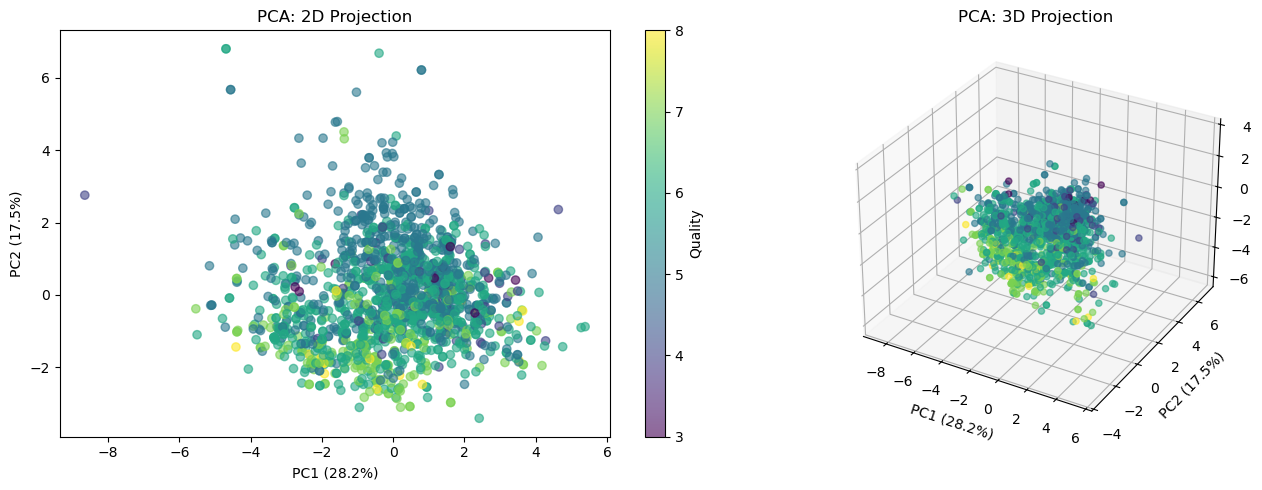

In [42]:
# Plot PCA projections
from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure(figsize=(14, 5))

ax1 = fig.add_subplot(121)
scatter1 = ax1.scatter(X_pca_2d[:, 0], X_pca_2d[:, 1], c=y, cmap='viridis', alpha=0.6)
ax1.set_xlabel(f'PC1 ({explained_variance_ratio[0]:.1%})')
ax1.set_ylabel(f'PC2 ({explained_variance_ratio[1]:.1%})')
ax1.set_title('PCA: 2D Projection')
plt.colorbar(scatter1, ax=ax1, label='Quality')
ax2 = fig.add_subplot(122, projection='3d')
scatter2 = ax2.scatter(X_pca_3d[:, 0], X_pca_3d[:, 1], X_pca_3d[:, 2], c=y, cmap='viridis', alpha=0.6)
ax2.set_xlabel(f'PC1 ({explained_variance_ratio[0]:.1%})')
ax2.set_ylabel(f'PC2 ({explained_variance_ratio[1]:.1%})')
ax2.set_zlabel(f'PC3 ({explained_variance_ratio[2]:.1%})')
ax2.set_title('PCA: 3D Projection')

plt.tight_layout()
plt.show()

k= 1 components -> Accuracy: 0.4062
k= 2 components -> Accuracy: 0.5125
k= 3 components -> Accuracy: 0.5437
k= 4 components -> Accuracy: 0.5500
k= 5 components -> Accuracy: 0.5375
k= 6 components -> Accuracy: 0.5406
k= 7 components -> Accuracy: 0.5656
k= 8 components -> Accuracy: 0.5719
k= 9 components -> Accuracy: 0.5625
k=10 components -> Accuracy: 0.5750
k=11 components -> Accuracy: 0.5750

Optimal k: 10 components -> Max Accuracy: 0.5750


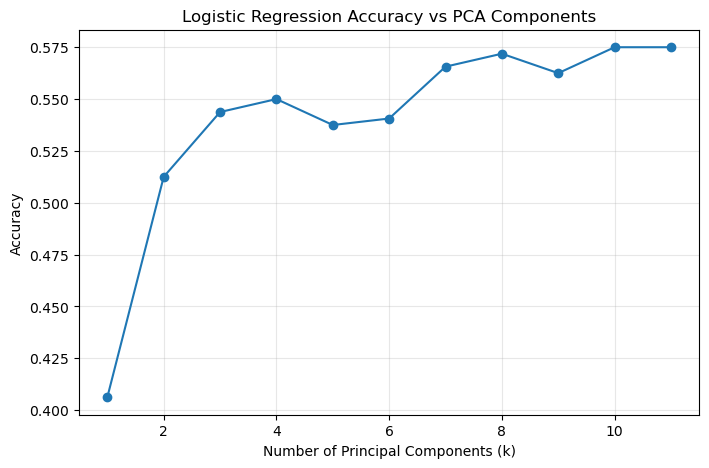

In [43]:
accuracies = []
k_values = range(1, p + 1)

for k in k_values:
    X_pca = project_pca(X_std_array, eigenvectors, k)
    X_train, X_test, y_train, y_test = train_test_split(X_pca, y, test_size=0.2, random_state=42)
    
    clf = LogisticRegression(max_iter=5000, random_state=42)
    clf.fit(X_train, y_train)
    y_pred = clf.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    accuracies.append(acc)
    print(f"k={k:2d} components -> Accuracy: {acc:.4f}")

plt.figure(figsize=(8, 5))
plt.plot(k_values, accuracies, marker='o')
plt.xlabel('Number of Principal Components (k)')
plt.ylabel('Accuracy')
plt.title('Logistic Regression Accuracy vs PCA Components')
plt.grid(True, alpha=0.3)
max_accuracy = max(accuracies)
optimal_k = k_values[np.argmax(accuracies)]
print(f"\nOptimal k: {optimal_k} components -> Max Accuracy: {max_accuracy:.4f}")
